In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from sklearn.calibration import calibration_curve

sys.path.append(str(Path("../src").resolve()))

In [2]:
df = pd.read_csv("../data/processed/shots_model_input.csv")
print(f"Loaded: {df.shape}")
df.head()

Loaded: (218700, 30)


,grid_type,game_id,game_event_id,player_id,player_name,team_id,team_name,period,minutes_remaining,seconds_remaining,...,shot_made_flag,game_date,htm,vtm,shot_angle,game_seconds_remaining,player_zone_fg_pct,shot_value,make_probability,xpts
0,Shot Chart Detail,22300018,12,1627749,Dejounte Murray,1610612737,Atlanta Hawks,1,10,56,...,1,20231114,DET,ATL,112.109448,656,0.480938,2,0.496020,0.992041
1,Shot Chart Detail,22300018,16,1630552,Jalen Johnson,1610612737,Atlanta Hawks,1,10,18,...,1,20231114,DET,ATL,138.613881,618,0.384058,3,0.381633,1.144900
2,Shot Chart Detail,22300018,25,203992,Bogdan Bogdanović,1610612737,Atlanta Hawks,1,9,34,...,1,20231114,DET,ATL,172.455071,574,0.480769,2,0.482224,0.964448
3,Shot Chart Detail,22300018,28,1629631,De'Andre Hunter,1610612737,Atlanta Hawks,1,9,2,...,1,20231114,DET,ATL,97.352379,542,0.638462,2,0.654354,1.308708
4,Shot Chart Detail,22300018,32,1627749,Dejounte Murray,1610612737,Atlanta Hawks,1,8,33,...,1,20231114,DET,ATL,12.094757,513,0.581169,2,0.605915,1.211830


In [3]:
FEATURE_COLUMNS = [
    "shot_distance",
    "shot_angle",
    "period",
    "game_seconds_remaining",
    "player_zone_fg_pct",
]

X = df[FEATURE_COLUMNS]
y = df["shot_made_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7, stratify=y
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"Make rate train: {y_train.mean():.3f}")
print(f"Make rate test:  {y_test.mean():.3f}")

Train: (174960, 5)
Test:  (43740, 5)
Make rate train: 0.474
Make rate test:  0.474


In [4]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=7,
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

print("Training complete.")

[0]	validation_0-logloss:0.68793
[50]	validation_0-logloss:0.63946
[100]	validation_0-logloss:0.63769
[150]	validation_0-logloss:0.63737
[200]	validation_0-logloss:0.63717
[250]	validation_0-logloss:0.63710
[299]	validation_0-logloss:0.63710
Training complete.


In [5]:
xgb_probs = xgb.predict_proba(X_test)[:, 1]

xgb_metrics = {
    "roc_auc": roc_auc_score(y_test, xgb_probs),
    "log_loss": log_loss(y_test, xgb_probs),
    "brier_score": brier_score_loss(y_test, xgb_probs),
}

print("XGBoost Metrics:")
for metric, value in xgb_metrics.items():
    print(f"  {metric}: {value:.4f}")

XGBoost Metrics:
  roc_auc: 0.6729
  log_loss: 0.6371
  brier_score: 0.2238


In [6]:
baseline_metrics = {
    "roc_auc": 0.6637,
    "log_loss": 0.6471,
    "brier_score": 0.2279,
}

comparison = pd.DataFrame({
    "Logistic Regression": baseline_metrics,
    "XGBoost": xgb_metrics,
}).T

comparison

,roc_auc,log_loss,brier_score
Logistic Regression,0.663700,0.647100,0.227900
XGBoost,0.672944,0.637102,0.223787


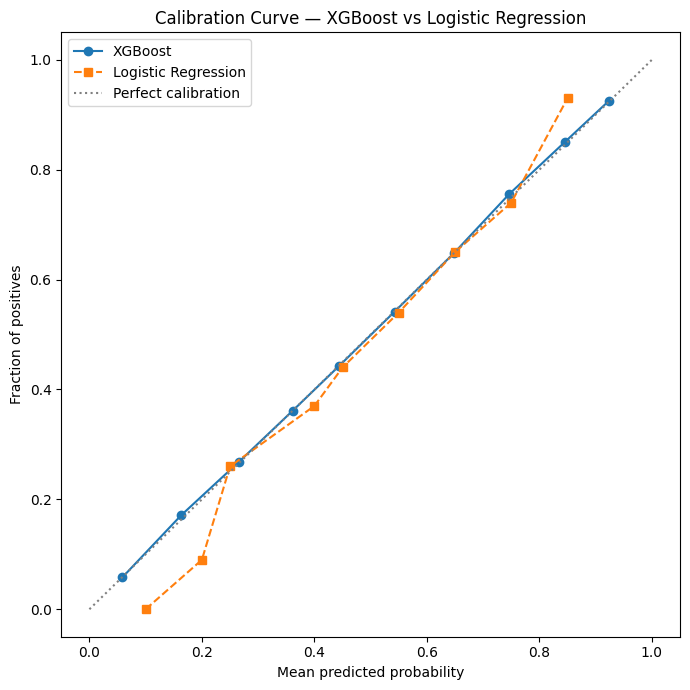

In [7]:
frac_pos_xgb, mean_pred_xgb = calibration_curve(y_test, xgb_probs, n_bins=10)

# Logistic regression baseline numbers from notebook 04
lr_baseline_x = [0.1, 0.2, 0.25, 0.4, 0.45, 0.55, 0.65, 0.75, 0.85]
lr_baseline_y = [0.0, 0.09, 0.26, 0.37, 0.44, 0.54, 0.65, 0.74, 0.93]

plt.figure(figsize=(7, 7))
plt.plot(mean_pred_xgb, frac_pos_xgb, marker="o", label="XGBoost")
plt.plot(lr_baseline_x, lr_baseline_y, marker="s", linestyle="--", label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle=":", color="gray", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve — XGBoost vs Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

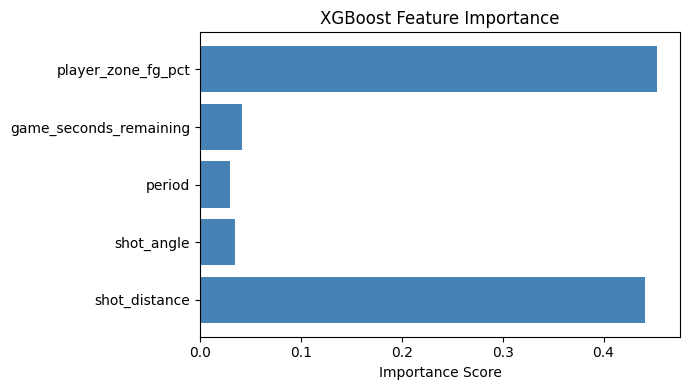

In [8]:
importances = xgb.feature_importances_

plt.figure(figsize=(7, 4))
plt.barh(FEATURE_COLUMNS, importances, color="steelblue")
plt.xlabel("Importance Score")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [9]:
df["xgb_make_probability"] = xgb.predict_proba(df[FEATURE_COLUMNS])[:, 1]
df["xgb_xpts"] = df["xgb_make_probability"] * df["shot_value"]

df[["player_name", "shot_zone_basic", "shot_value", "xgb_make_probability", "xgb_xpts"]].head(10)

,player_name,shot_zone_basic,shot_value,xgb_make_probability,xgb_xpts
0,Dejounte Murray,In The Paint (Non-RA),2,0.467761,0.935523
1,Jalen Johnson,Above the Break 3,3,0.401250,1.203751
2,Bogdan Bogdanović,Mid-Range,2,0.509046,1.018091
3,De'Andre Hunter,Restricted Area,2,0.544129,1.088257
4,Dejounte Murray,Restricted Area,2,0.496926,0.993852
5,De'Andre Hunter,Restricted Area,2,0.594645,1.189289
6,Clint Capela,In The Paint (Non-RA),2,0.468600,0.937199
7,De'Andre Hunter,In The Paint (Non-RA),2,0.436695,0.873390
8,Dejounte Murray,Restricted Area,2,0.500646,1.001292
9,Clint Capela,Restricted Area,2,0.588419,1.176838


In [10]:
df["xgb_xpts"].describe()

count    218700.000000
mean          1.092324
std           0.285521
min           0.015244
25%           0.905656
50%           1.074958
75%           1.242788
max           2.964453
Name: xgb_xpts, dtype: float64

In [11]:
df.nlargest(10, "xgb_xpts")[
    ["player_name", "shot_zone_basic", "shot_distance", "shot_value", "xgb_make_probability", "xgb_xpts"]
]

,player_name,shot_zone_basic,shot_distance,shot_value,xgb_make_probability,xgb_xpts
94537,Ryan Rollins,Left Corner 3,224.570702,3,0.988151,2.964453
81196,Orlando Robinson,Right Corner 3,223.008968,3,0.987973,2.963918
168857,Olivier Sarr,Right Corner 3,232.744495,3,0.987664,2.962991
153582,Jordan Ford,Above the Break 3,259.532272,3,0.987515,2.962545
145151,Isaiah Thomas,Left Corner 3,230.176020,3,0.987331,2.961993
101084,Leonard Miller,Left Corner 3,221.273586,3,0.987061,2.961184
81637,Dru Smith,Left Corner 3,240.208243,3,0.987000,2.961001
137142,D.J. Wilson,Above the Break 3,253.339693,3,0.986886,2.960657
21935,Pete Nance,Above the Break 3,262.908729,3,0.986486,2.959457
195992,Brandon Clarke,Left Corner 3,234.337364,3,0.986201,2.958604


In [12]:
player_summary = (
    df.groupby("player_name")
    .agg(
        attempts=("xgb_xpts", "count"),
        avg_xgb_xpts=("xgb_xpts", "mean"),
        avg_make_prob=("xgb_make_probability", "mean"),
        actual_fg_pct=("shot_made_flag", "mean"),
    )
    .query("attempts >= 100")
    .sort_values("avg_xgb_xpts", ascending=False)
    .head(20)
)
player_summary

,attempts,avg_xgb_xpts,avg_make_prob,actual_fg_pct
player_name,,,,
Dereck Lively II,296,1.525257,0.762311,0.746622
Daniel Gafford,480,1.454380,0.727190,0.725000
Jaxson Hayes,175,1.451200,0.724083,0.720000
Luke Kornet,203,1.411187,0.703185,0.699507
Dwight Powell,106,1.395880,0.692704,0.679245
Nick Richards,376,1.386713,0.693216,0.691489
Trayce Jackson-Davis,332,1.373759,0.686865,0.701807
Isaiah Jackson,233,1.372329,0.685422,0.665236
Rudy Gobert,614,1.358697,0.679241,0.661238


In [13]:
# Players beating or falling short of their shot quality expectations
player_summary["xpts_diff"] = player_summary["actual_fg_pct"] - player_summary["avg_make_prob"]

print("Biggest overperformers (making more than expected):")
print(player_summary.nlargest(5, "xpts_diff")[["attempts", "avg_make_prob", "actual_fg_pct", "xpts_diff"]])

print("\nBiggest underperformers (making less than expected):")
print(player_summary.nsmallest(5, "xpts_diff")[["attempts", "avg_make_prob", "actual_fg_pct", "xpts_diff"]])

Biggest overperformers (making more than expected):
                      attempts  avg_make_prob  actual_fg_pct  xpts_diff
player_name                                                            
Bol Bol                    151       0.578029       0.615894   0.037865
Trayce Jackson-Davis       332       0.686865       0.701807   0.014942
Mark Williams              151       0.644864       0.649007   0.004143
Nick Richards              376       0.693216       0.691489  -0.001726
Daniel Gafford             480       0.727190       0.725000  -0.002190

Biggest underperformers (making less than expected):
                    attempts  avg_make_prob  actual_fg_pct  xpts_diff
player_name                                                          
Isaiah Hartenstein       365       0.670351       0.643836  -0.026515
Isaiah Jackson           233       0.685422       0.665236  -0.020185
Onyeka Okongwu           365       0.630449       0.610959  -0.019490
Rudy Gobert              614       0.679

In [15]:
df["xpts"] = df["xgb_xpts"]
df.to_csv(output_path, index=False)

In [16]:
output_path = Path("../data/processed/shots_model_input.csv")
df.to_csv(output_path, index=False)
print(f"Saved final dataset: {df.shape}")
print(f"New columns: xgb_make_probability, xgb_xpts")

Saved final dataset: (218700, 32)
New columns: xgb_make_probability, xgb_xpts
